In [1]:
# TODO: pip install dependencies

In [2]:
from inference_sdk import InferenceHTTPClient

API_KEY = "BecfnYVBMM9izzi5ITWp"

CLIENT = InferenceHTTPClient(api_url="http://localhost:9001", api_key=API_KEY)

SEGMENTATION_MODEL_ID = "rfdetr-seg-preview"
SAM3_3D_MODEL_ID = "sam3-3d-objects"

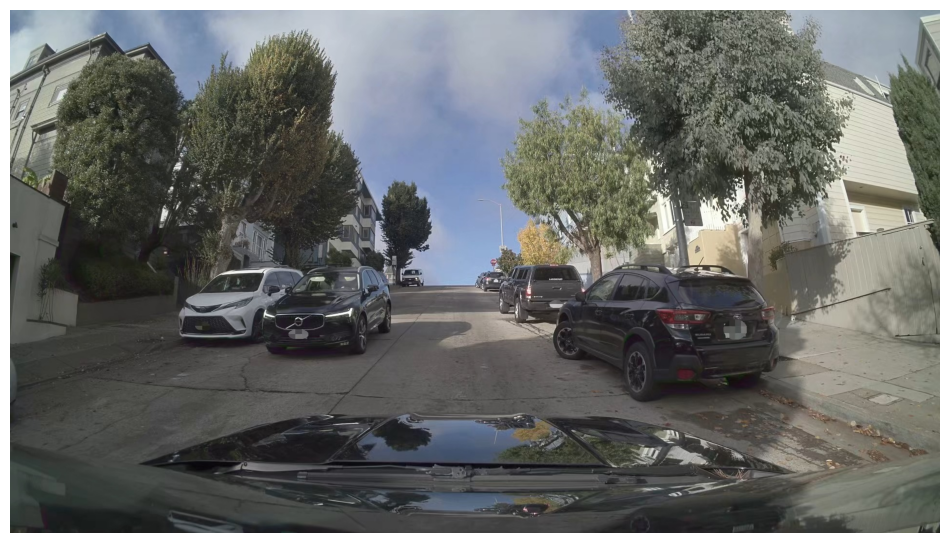

In [3]:
import supervision as sv
from PIL import Image

image = Image.open("sample_data/original.jpg")
sv.plot_image(image)

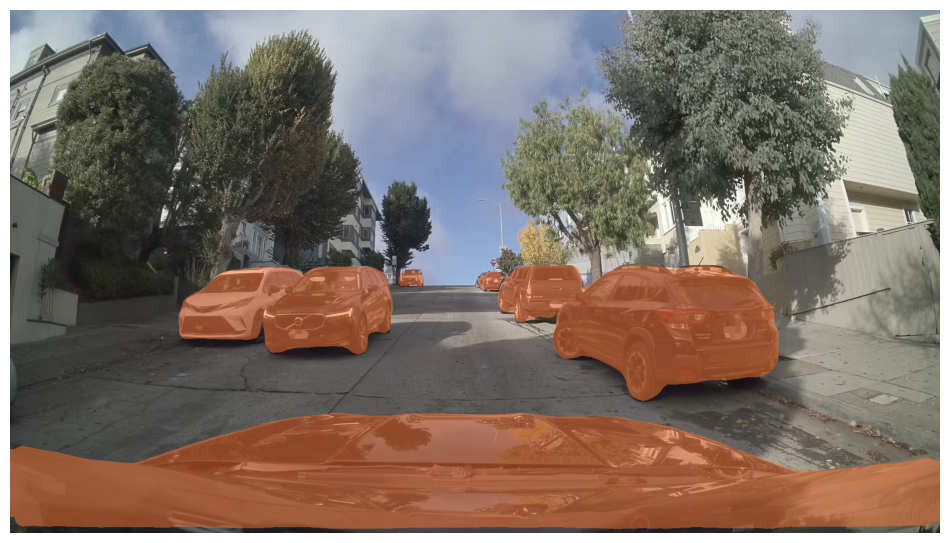

In [4]:

seg_result = CLIENT.infer(image, model_id=SEGMENTATION_MODEL_ID)
detections = sv.Detections.from_inference(seg_result)

mask_annotator = sv.MaskAnnotator()
annotated = mask_annotator.annotate(scene=image.copy(), detections=detections)
sv.plot_image(annotated)

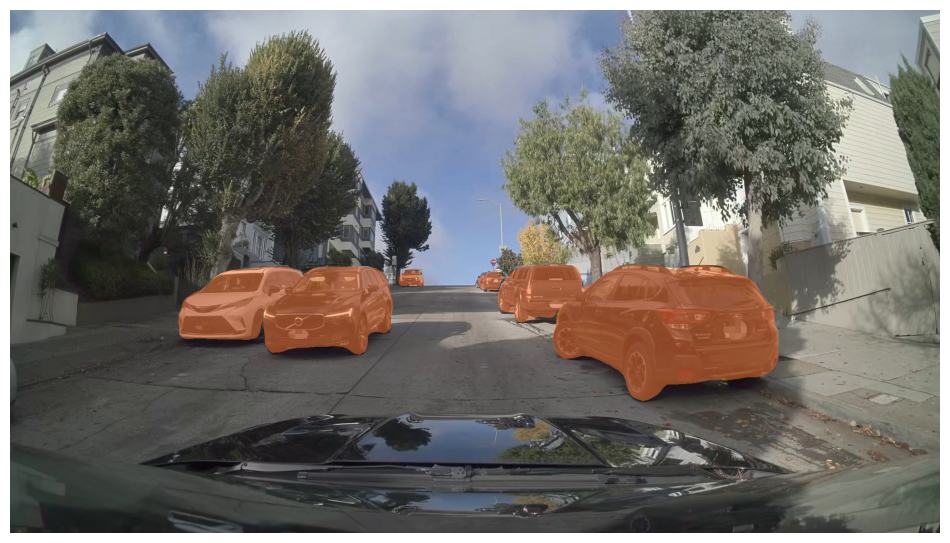

In [5]:
from copy import deepcopy
import numpy as np

# filter out ego-vehicle (simple heuristic: the widest mask - ego take up most of the image width)
ego_pred_idx = np.argmax([p["width"] for p in seg_result["predictions"]])
result_without_ego = deepcopy(seg_result)
result_without_ego["predictions"].pop(ego_pred_idx)

detections_without_ego = sv.Detections.from_inference(result_without_ego)
annotated_without_ego = mask_annotator.annotate(
    scene=image.copy(), detections=detections_without_ego
)
sv.plot_image(annotated_without_ego)

In [ ]:
from itertools import chain

# mask polygons in the expected [x1 y1 x2 y2 ... xN yN] format
mask_input = [
    list(chain.from_iterable([[pt["x"], pt["y"]] for pt in p["points"]]))
    for p in result_without_ego["predictions"]
]

sam3_3d_result = CLIENT.sam3_3d_infer(inference_input=image, mask_input=mask_input)

In [ ]:
from base64 import b64decode
import torch
import rerun as rr

from pytorch3d.transforms.rotation_conversions import quaternion_to_matrix

rr.init("rf-mot3d")
rr.log("/", rr.ViewCoordinates.RIGHT_HAND_Y_UP, rr.TransformAxes3D(0.5), static=True)

rr.set_time("tick", sequence=0)
rr.log("/camera/image/rgb", rr.Image(annotated_without_ego))

z_to_y_up = torch.tensor([[1, 0, 0], [0, 0, -1], [0, 1, 0]], dtype=torch.float)
y_to_z_up = torch.tensor([[1, 0, 0], [0, 0, 1], [0, -1, 0]], dtype=torch.float)
# Final scene correction applied by make_scene_glb after transform_glb_to_world.
# Must be incorporated into InstancePoses3D since individual GLBs don't have it baked in.
R_view = torch.tensor([[-1, 0, 0], [0, 0, -1], [0, -1, 0]], dtype=torch.float)

for i, obj in enumerate(sam3_3d_result["objects"]):
    if obj["mesh_glb"] is None:
        print(f"No mesh available for object_{i}")
        continue
    
    mesh_glb = b64decode(obj["mesh_glb"])
    metadata = obj["metadata"]

    t = torch.tensor(metadata["translation"], dtype=torch.float)
    R = quaternion_to_matrix(torch.tensor(metadata["rotation"], dtype=torch.float))
    s = torch.tensor(metadata["scale"], dtype=torch.float)

    # 1. Z-up → Y-up coordinate conversion (row-vector convention throughout SAM3D)
    # 2. PyTorch3D quaternion_to_matrix is column-vector (R @ v), but SAM3D uses it
    #    row-vector (v @ R), so pass R.T to Rerun's column-vector mat3x3
    # 3. R_view: global scene correction from make_scene_glb, applied in world space
    t = t @ z_to_y_up @ R_view
    R = R_view @ y_to_z_up @ R.T @ z_to_y_up

    obj_id = f"object_{i}/mesh"
    rr.log(
        obj_id,
        rr.Asset3D(contents=mesh_glb),
        rr.Transform3D(translation=t, mat3x3=R, scale=s),
    )

rr.notebook_show()